### Community detection II

In this notebook, we will learn how to use graph-tool, an efficient package to characterize network structure and get its community structure based on a Bayesian approach.

#### The following two cells are thought to install graph-tool in a Google Collab environment

The installation procedure of this package varies across operative systems. Check https://graph-tool.skewed.de/installation.html for further details.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

RuntimeError: This module must ONLY run as part of a Colab notebook!

In [2]:
!mamba install -q graph-tool

zsh:1: command not found: mamba


Now we have installed the dependencies needed to run graph-tool. With this notebook, we will explore some advantages of graph-tool and compare its results with those obtained by modularity maximization techniques

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import networkx as nx
import random as random
import pandas as pd
import graph_tool.all as gt

ModuleNotFoundError: No module named 'graph_tool'

We first upload the data manually to the content folder within the Collab session and load it

In [2]:
df=pd.read_csv('/content/books.csv')

df_book1=df[df['book']==1.0]

In [3]:
def dataframe_to_graphtool(df, source_col, target_col, weight_col=None):
    """
    Converts a pandas DataFrame to a graph_tool Graph.

    Parameters:
    - df: pandas DataFrame containing edges
    - source_col: column name for source nodes
    - target_col: column name for target nodes
    - weight_col: optional column name for edge weights

    Returns:
    - graph_tool.Graph object with edges and optional weights
    - edge property map for weights (None if no weights)
    - dictionary mapping vertex indices to node labels
    """
    g = gt.Graph(directed=False)  # Change to True for a directed graph
    vertex_map = {}  # Maps node labels to vertex objects
    ID_to_label={} # Maps node ID to node label

    # Add vertices
    count=0
    for node in pd.concat([df[source_col], df[target_col]]).unique():
        vertex_map[node] = g.add_vertex()
        ID_to_label[count] = node
        count+=1

    # Add edges and weights if applicable
    weight_prop = g.new_edge_property("double") if weight_col else None


    for _, row in df.iterrows():
        src = vertex_map[row[source_col]]
        tgt = vertex_map[row[target_col]]
        edge = g.add_edge(src, tgt)

        if weight_col:
            weight_prop[edge] = row[weight_col]

    if weight_col:
        g.edge_properties["weight"] = weight_prop  # Store weights in graph

    return g,weight_prop,ID_to_label


In [4]:
g,weight_prop,ID_to_label=dataframe_to_graphtool(df_book1,'Source','Target',weight_col='weight')

### g is the graph object inside graph-tool (equivalent to nx.Graph())
### weight_prop contains the value of the weight for each edge
### ID_to_label is the dictionary allowing us to translate the ID of the node in the graph (always from 0 to N-1) to the original label


We can also use graph-tool as a package to characterize the macroscopic/microscopic structure of networks

In [10]:
# Compute degree and strength (weighted degree)

vertices = g.get_vertices()
degrees = g.get_total_degrees(vertices)
strengths = np.zeros(len(vertices))  # Initialize strength array

for v in vertices:
    strengths[v] = sum([weight_prop[e] for e in g.edges() if e.source()==v or e.target()==v])  # Sum of weights on edges

In [11]:
## Compute centrality indicators
page_rank = gt.pagerank(g)
node_betweenness,edge_betweenness=gt.betweenness(g)
eigenvector_centrality=gt.eigenvector(g,weight=weight_prop)

In [7]:
degrees

array([ 2,  2,  7,  6,  6,  3, 10,  5,  1, 27,  1,  2,  2, 14, 14,  6,  5,
        5, 32,  6, 10, 11, 43,  3, 30,  1,  3,  3,  1,  4,  2,  3, 21,  3,
        1,  2,  2,  1,  1,  6, 19,  1, 66, 11,  3,  1,  6,  3,  5, 12,  7,
        1,  6,  8,  5,  4,  1,  2,  2,  1,  4,  2,  5,  1,  6,  6,  9,  8,
        1, 29,  7,  4, 13,  6,  5,  6, 30,  2, 15, 37,  8,  1, 13, 21,  2,
        2,  3,  3,  1,  1,  1, 14, 18,  4,  1, 15,  2,  2,  1,  5,  5,  9,
        6,  1, 11,  2,  5,  7,  4,  3, 26, 14,  7,  7,  5,  1,  6,  2, 18,
        7, 10,  9, 35,  3, 50, 18,  5, 16, 35,  2,  6, 12,  2, 15,  2,  8,
       46, 22,  3,  1, 12,  5,  7,  3,  5,  7, 17,  1,  1,  1,  2,  2,  6,
        6,  2,  7,  1,  1,  1,  1,  1,  3,  2,  1,  1,  8,  2,  3,  3,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  4,  1,  2,  1,  4,  1,  1,  1,  1],
      dtype=uint64)

In [12]:
strengths

array([   9.,    9.,   74.,   37.,   36.,   11.,   80.,   32.,    4.,
        430.,    3.,    7.,    6.,  143.,  104.,   28.,   26.,   28.,
        531.,   41.,  109.,   69.,  520.,   16.,  424.,    5.,   19.,
         16.,    4.,   29.,    7.,   20.,  443.,    9.,    6.,    6.,
          7.,    7.,    7.,   51.,  256.,    4., 1284.,   48.,    9.,
          4.,   23.,   29.,   17.,   74.,   85.,    7.,   45.,   56.,
         37.,   18.,    3.,    8.,    8.,    5.,   52.,    6.,   24.,
          3.,   20.,   70.,   43.,   81.,    3.,  241.,   25.,   24.,
        181.,   54.,   60.,   43.,  422.,    6.,  169.,  784.,   39.,
          3.,  154.,  152.,    7.,   11.,   11.,   28.,    5.,    3.,
          4.,   78.,  210.,   36.,    3.,  138.,    6.,    8.,    4.,
         29.,   18.,   36.,   63.,   20.,  141.,   10.,   50.,   54.,
         33.,   31.,  313.,  150.,  107.,   68.,   21.,    5.,   26.,
         12.,  186.,   53.,   46.,   98.,  516.,   20.,  941.,  124.,
         19.,  135.,

Apart from using graph-tool as a library to analyze the structure of network, we can implement the inference of the modular structure based on the Bayesian approach explained in the lecture and the stochastic block model

In [13]:
realizations=10
for realization in range(realizations):
  state = gt.minimize_blockmodel_dl(g, state_args={'deg_corr': True})

  # Get community assignments
  blocks = state.get_blocks()
  print('Description length of realization %d is: %.3lf'%(realization,state.entropy()))


Description length of realization 0 is: 2154.744
Description length of realization 1 is: 2144.097
Description length of realization 2 is: 2149.349
Description length of realization 3 is: 2148.214
Description length of realization 4 is: 2161.434
Description length of realization 5 is: 2137.279
Description length of realization 6 is: 2145.601
Description length of realization 7 is: 2142.730
Description length of realization 8 is: 2144.512
Description length of realization 9 is: 2149.356


The Bayesian inference of communtiies relying on the stochsatic block model is stochastic by nature. In case the function to be optimized is not peaked around the maximum, the algorithm might return different partitions with varying description length. If we aim at providing the partition with the maximum likelihood, we should just keep that with the shortest description length.


In [27]:
realizations=500
for realization in range(realizations):
  state = gt.minimize_blockmodel_dl(g, state_args={'deg_corr': True})
  if realization==0:
    min_description_length=state.entropy()
    state_min=state
  else:
    if state.entropy()<min_description_length:
      min_description_length=state.entropy()
      print('The description length of the best partition explored so far is',min_description_length)
      state_min=state
  # Get community assignments
blocks = state_min.get_blocks()
community_dict = {int(v): int(blocks[v]) for v in g.vertices()}

The description length of the best partition explored so far is 2142.8314409649165
The description length of the best partition explored so far is 2140.382168276206
The description length of the best partition explored so far is 2138.9278529851867
The description length of the best partition explored so far is 2137.1819031688638
The description length of the best partition explored so far is 2133.677645339028


In [28]:
communities_unique_IDs=list(set(community_dict.values()))
communities_unique_IDs

[35, 41, 137, 79, 153, 27]

For optimization purposes related to the implementation of the code in c++, the ID of the blocks does not follow any coherent ordering. Moreover, the ID of the nodes corresponds with integers from 0 to N-1. Now we will translate the information to an amenable format for networkx

In [29]:
from collections import defaultdict
def convert_to_networkx_format(community_dict):
    """
    Converts a {node: community} dictionary into the NetworkX community format (list of sets).

    Parameters:
    - community_dict: Dictionary mapping nodes to community labels

    Returns:
    - List of sets, where each set contains nodes belonging to the same community
    """
    community_groups = defaultdict(set)

    for node, community in community_dict.items():
        community_groups[community].add(ID_to_label[node])

    return list(community_groups.values())


communities_SBM=convert_to_networkx_format(community_dict)

In [30]:
def set_color_nodes(communities,G):
    colors=plt.cm.jet(np.linspace(0,1,len(communities))) ## Get the colors for the communities
    community_node={} ## Dictionary to store the community of each node
    count_community=0 ## Counter for the communities' labels

    for community in communities: ## For each community
        for node in community: ## For each node in the community
            community_node[node]=count_community ## Store the label of the community of the node
        count_community=count_community+1 ## Update the counter

    color_nodes=[] ## List to store the color of each node
    for node in G.nodes():
        color_nodes.append(colors[community_node[node]]) ## Get the color of the node

    return color_nodes

In [34]:
G=nx.from_pandas_edgelist(df_book1,'Source','Target',edge_attr='weight')
color_communities_SBM=set_color_nodes(communities_SBM,G)
communities_louvain=nx.community.louvain_communities(G)
color_communities_louvain=set_color_nodes(communities_louvain,G)

In [36]:
print('The number of communities according to the Louvain algorithm is',len(communities_louvain))
print('The number of communities according to the SBM method is',len(communities_SBM))

The number of communities according to the Louvain algorithm is 8
The number of communities according to the SBM method is 6


We compare the partitions obtained by the Louvain algorithm and the SBM.

(np.float64(-0.674061970694176),
 np.float64(1.121444284192663),
 np.float64(-1.0274469954861591),
 np.float64(1.192653334412712))

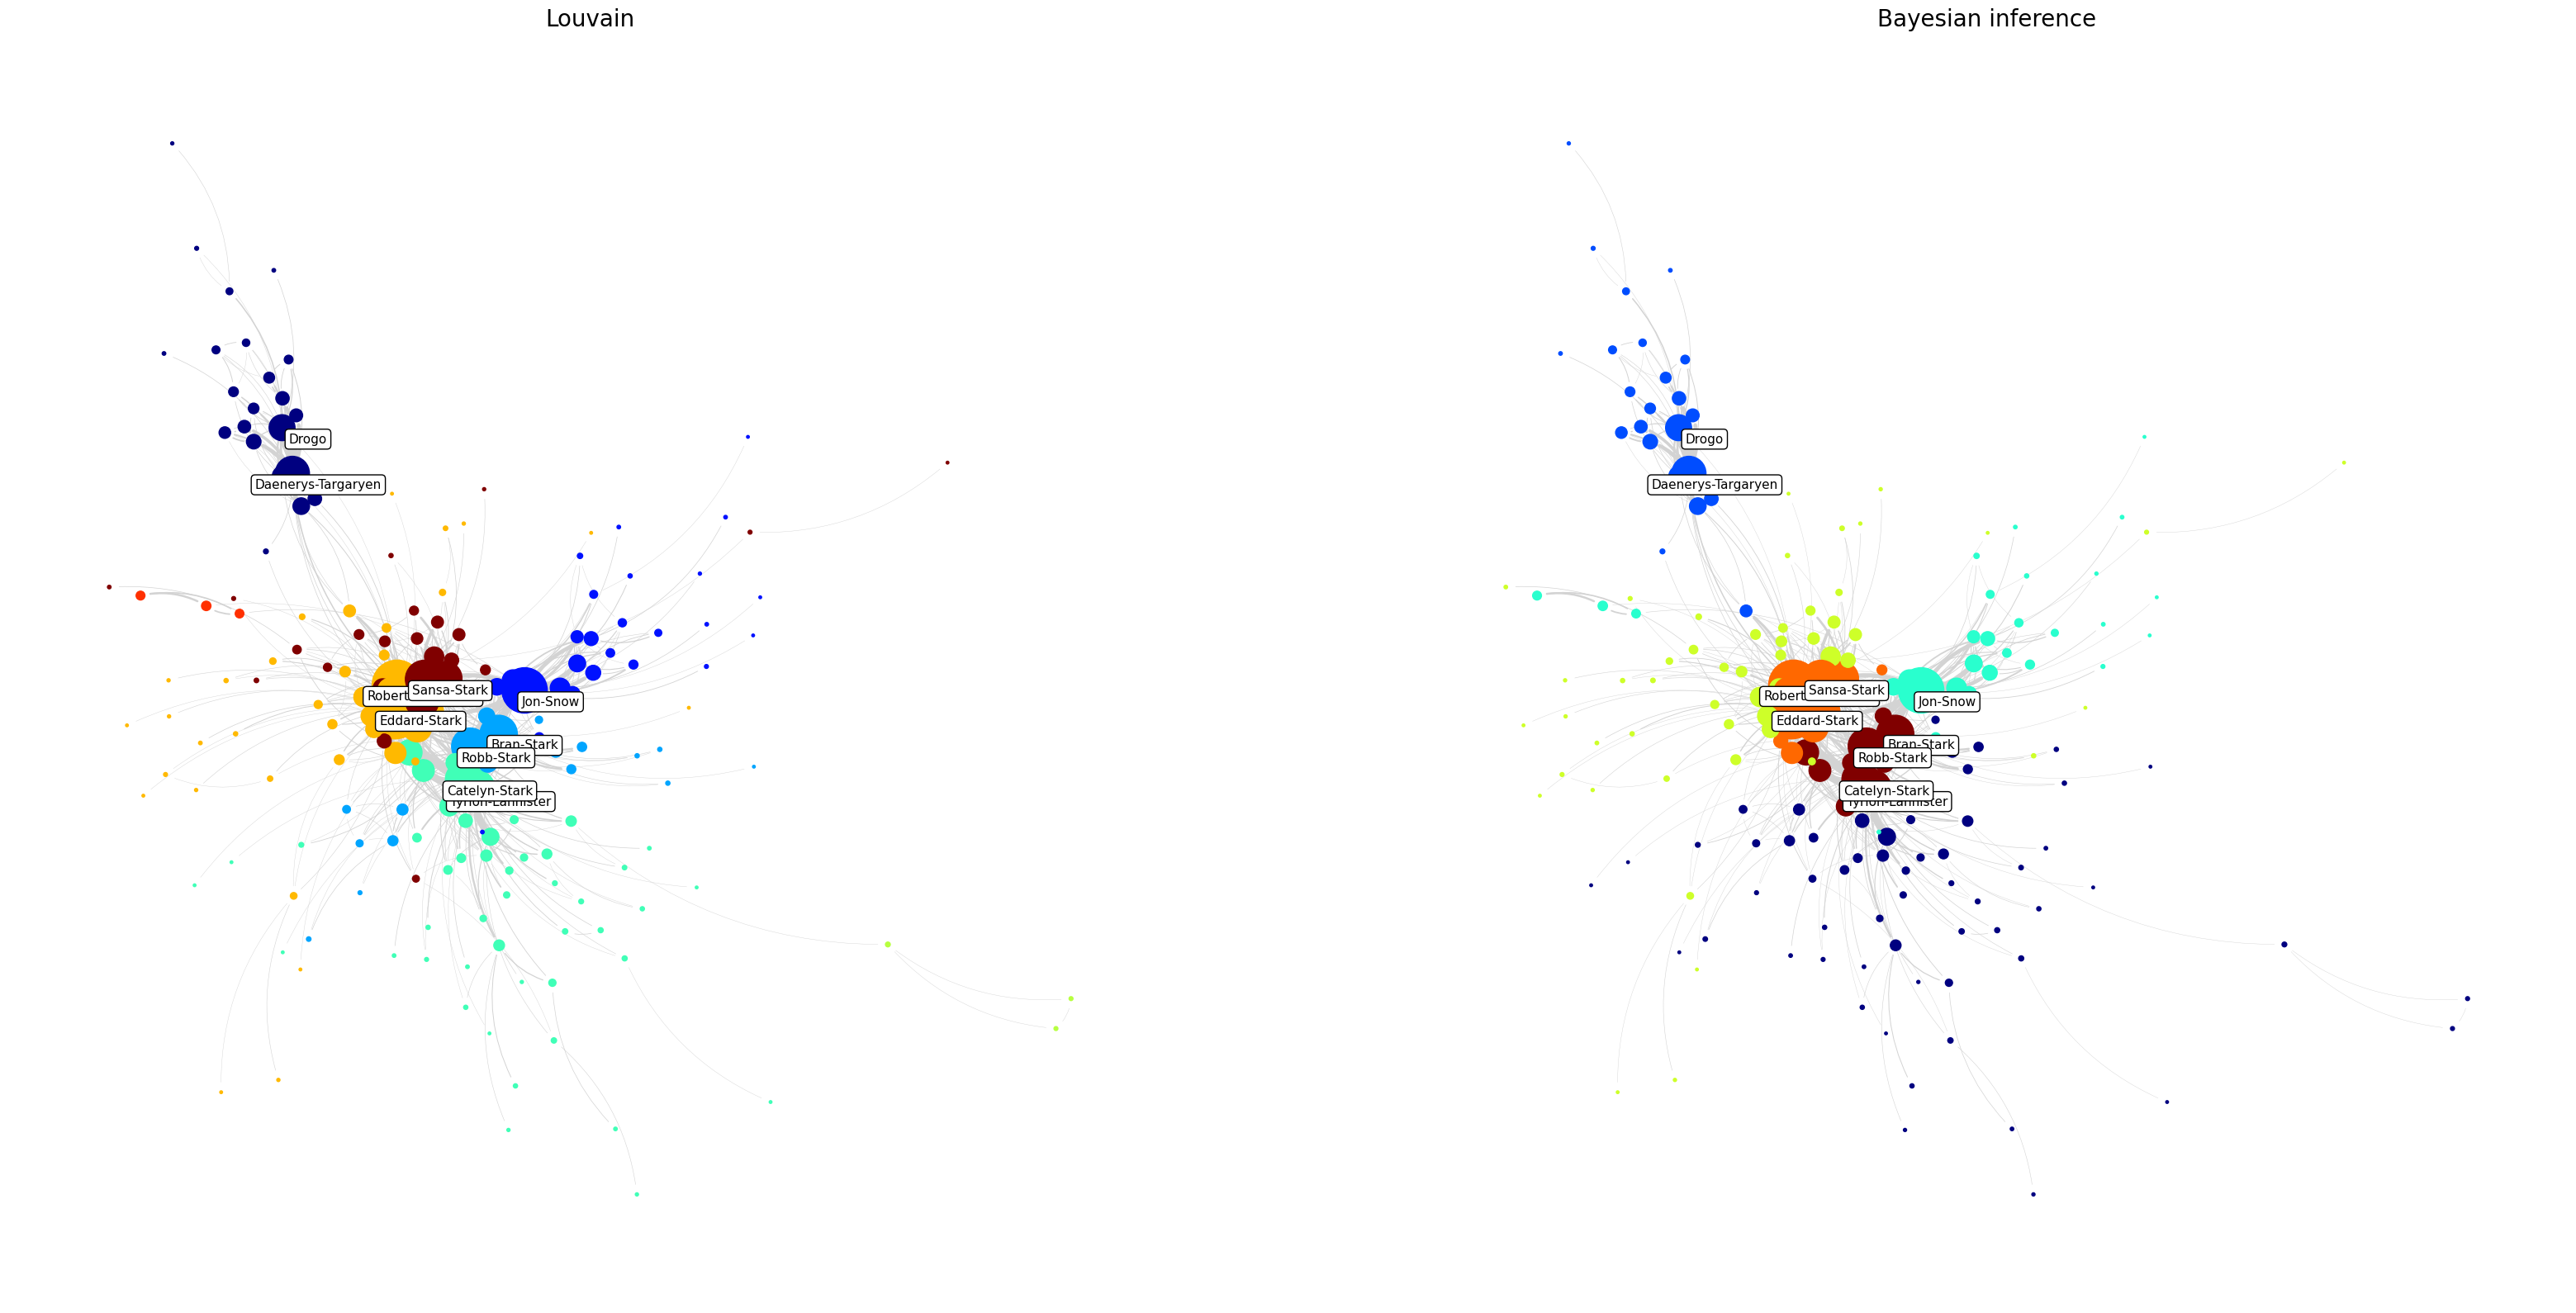

In [37]:
fig,ax=plt.subplots(1,2,figsize=(40,20))

betweennes_centralities=nx.betweenness_centrality(G)

## Find the 10 nodes with highest betweenness centralities

highest_betweenness_nodes = sorted(betweennes_centralities, key=betweennes_centralities.get, reverse=True)[:10]

labels = {}
for node in G.nodes():
    if node in highest_betweenness_nodes:
        #set the node name as the key and the label as its value
        labels[node] = node


### We fix the position of the nodes

positions=nx.spring_layout(G,k=.2,weight='weight',seed=1)

## Size proportional to strength
sizes=[2*G.degree(node,weight='weight') for node in G.nodes()]


## Coordinates of the nodes' labels
pos_attrs = {}
for node, coords in positions.items():
    if node in highest_betweenness_nodes:
        pos_attrs[node] = (coords[0]+0.04, coords[1] - 0.02)

thickness=[.1*G.edges()[edge]['weight'] for edge in G.edges()]

## We represent the network fixing the positions.
nx.draw_networkx_nodes(G,pos=positions,node_size=sizes,ax=ax[0],node_color=color_communities_louvain)
nx.draw_networkx_labels(G,pos=pos_attrs,labels=labels,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=.3'),font_size=11,ax=ax[0])
nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness,ax=ax[0])

nx.draw_networkx_nodes(G,pos=positions,node_size=sizes,ax=ax[1],node_color=color_communities_SBM)
nx.draw_networkx_labels(G,pos=pos_attrs,labels=labels,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=.3'),font_size=11,ax=ax[1])
nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness,ax=ax[1])

ax[0].set_title('Louvain',fontsize=20)
ax[1].set_title('Bayesian inference',fontsize=20)

ax[0].axis('off')
ax[1].axis('off')

The Bayesian approach allows us not only to get the solution with maximum likelihood but also to explore the posterior probability landscape of all the partitions. For instance, we can ask ourselves what is the probability that the underlying network possess more than one module, i.e. has some modular structure

In [38]:
h = np.zeros(g.num_vertices() + 1) ### h is the dictionary containing the number of blocks in the network

def collect_num_groups(s):
    B = s.get_nonempty_B()
    h[B] += 1

# Now we collect partitions for exactly 20,000 sweeps, at intervals
# of 10 sweeps:
gt.mcmc_equilibrate(state, force_niter=1000, mcmc_args=dict(niter=20),
                    callback=collect_num_groups)

(2175.99243416793, 15446662, 3690716)

Text(0.5, 0, 'Number of blocks (B)')

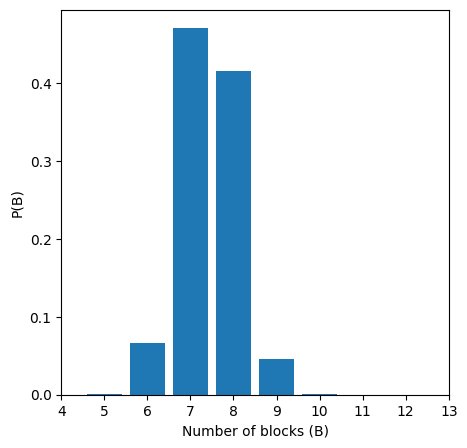

In [39]:
number_blocks=range(0,len(h))
h=h/np.sum(h)
fig,ax=plt.subplots(1,1,figsize=(5,5))
ax.bar(number_blocks,h)
ax.set_xlim(4,13)
ax.set_ylabel('P(B)')
ax.set_xlabel('Number of blocks (B)')

In [40]:
len(communities_unique_IDs)

6

### Model selection: Should we use the degree-corrected SBM or the SBM? Remember that the SBM just assumes the existence of ER networks both within and between modules whereas the degre-corrected SBM can accommodate hubs

In [41]:
realizations=60
for realization in range(realizations):
  state_dc = gt.minimize_blockmodel_dl(g, state_args={'deg_corr': True})
  state_ndc = gt.minimize_blockmodel_dl(g, state_args={'deg_corr': False})
  if realization==0:
    min_description_length_dc=state_dc.entropy()
    min_description_length_ndc=state_ndc.entropy()
    state_dc_min=state_dc
    state_ndc_min=state_ndc
  else:
    if state_dc.entropy()<min_description_length_dc:
      min_description_length_dc=state_dc.entropy()
      state_dc_min=state_dc
    if state_ndc.entropy()<min_description_length_ndc:
      min_description_length_ndc=state_ndc.entropy()
      state_ndc_min=state_ndc


print('DL for non-degree corrected model:',min_description_length_ndc)
print('DL for degree corrected model:',min_description_length_dc)


DL for non-degree corrected model: 2170.606261497914
DL for degree corrected model: 2136.3228260605224


Our network is better described by the degree-corrected SBM

In [42]:
blocks_dc = state_dc_min.get_blocks()
num_blocks_dc = len(set(blocks_dc.a))

blocks_ndc = state_ndc_min.get_blocks()
num_blocks_ndc = len(set(blocks_ndc.a))

print('The number of blocks in the non-degree corrected model is',num_blocks_ndc)
print('The number of blocks in the degree corrected model is',num_blocks_dc)

The number of blocks in the non-degree corrected model is 9
The number of blocks in the degree corrected model is 6
